In [39]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans

## 請安裝
> pip install opencv-python

# Problem : K-Means Clustering
**K-Means Clustering** is an unsupervised learning algorithm for data grouping. In image segmen- tation, it can be applied to partition image pixels into different groups based on the associated pixel values or features. In this problem, you will learn how to segment the provided image by using K-means clustering.

In [40]:
img = cv2.imread('data/bird.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## 1-1. cluster with only RGB values

In [41]:
def km_clust(array, n_clusters):   
    # Define the k-means clustering problem
    k_m = KMeans(n_clusters = n_clusters)
    # Solve the k-means clustering problem
    k_m.fit(array)
    # Get the coordinates of the clusters centres
    center = k_m.cluster_centers_
    print(center)
    # Get the label of each point
    label = k_m.labels_
    return(label, center)

(1024, 1024, 3)
[[163.20219796 197.60564191 120.55287464]
 [107.19812802  95.11501853  71.22564982]]
center= [[163 197 120]
 [107  95  71]]


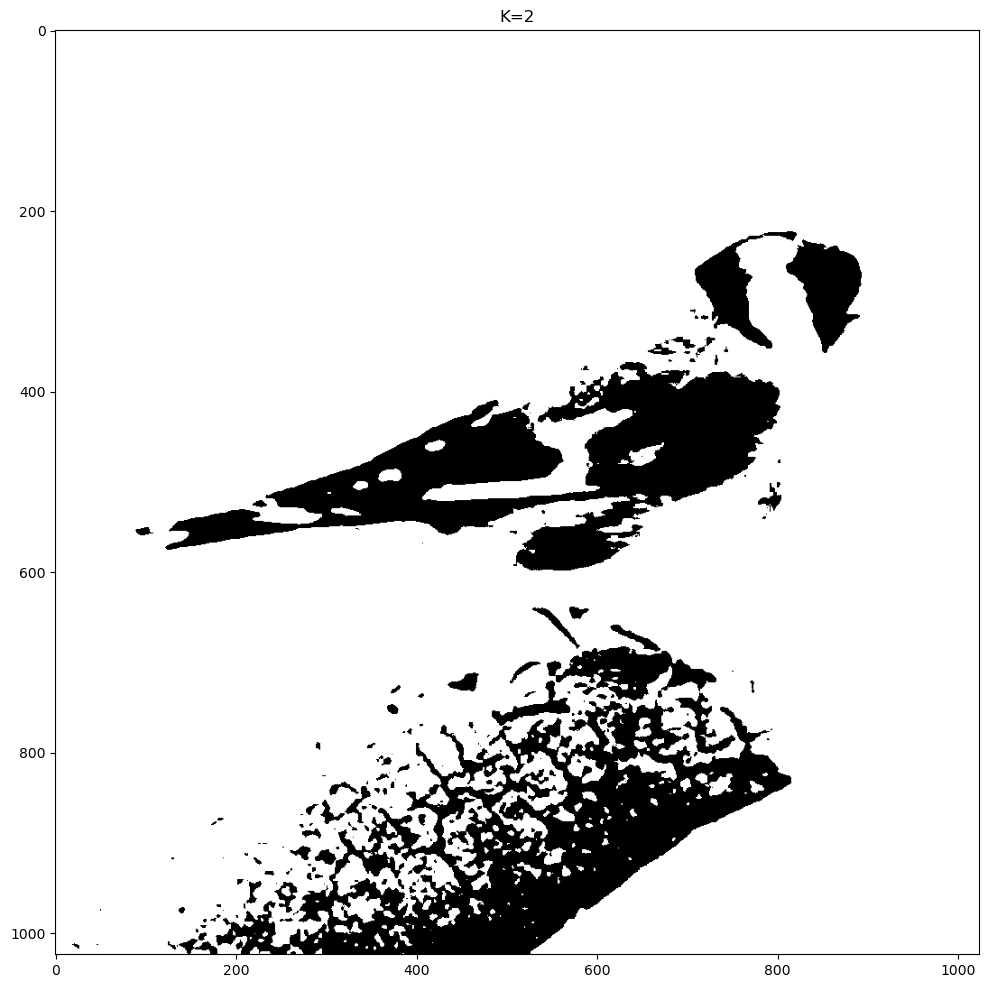

In [42]:
h,w,g=img.shape
print(img.shape)
#其中 -1 代表讓 NumPy 自動計算這個維度的大小。
#每一列代表一個像素的顏色：
#在 KMeans image segmentation 裡，Z 就是拿來丟給 KMeans 的資料，每一列代表一個像素的顏色：
Z=img.reshape((-1,3))
Z.shape
K=2
label,center=km_clust(Z,K)

center=np.uint8(center[:,:3])
print("center=",center)
#center
center = np.array([
    [255, 255, 255],
    [0, 0, 0]
], dtype=np.uint8)

label.shape

res=center[label.flatten()]
res=res.reshape(img.shape)

plt.figure(figsize=(16,12))
plt.title("K={}".format(K))
plt.imshow(res)




[[107.10538886  95.02824543  71.15157414]
 [163.19717208 197.58314734 120.54722846]]
[[107.10538886  95.02824543  71.15157414]
 [163.19717208 197.58314734 120.54722846]]
[[162.53923253 211.14980559 119.01241677]
 [ 96.47120787  81.47877653  49.03643883]
 [152.28509372 136.43070187 109.6700643 ]
 [191.89254306 172.8135764  133.31485892]
 [ 30.01423041  38.30501203  44.57434341]
 [157.86548881 195.20999036 108.85732948]
 [188.48153238 187.93597893 181.46063105]
 [166.81650432 152.42282411 120.97172725]
 [165.32030895 143.24943208  90.340209  ]
 [ 79.26926806  89.50557441  92.70019389]
 [132.99524469 113.93836565  73.91144968]
 [233.20268219 209.57489879  37.79605263]
 [140.64850485 182.31294645 107.28713237]
 [ 45.93590219  57.42521922  72.07607756]
 [145.99662793 142.28066478 129.85993858]
 [172.01551624 203.62920534 137.5304041 ]
 [163.71071226 160.45833672 144.28205961]
 [170.25990271  56.94579569  53.12647672]
 [178.46274985 139.0984252   31.52301635]
 [156.25680148 191.06403759 115.

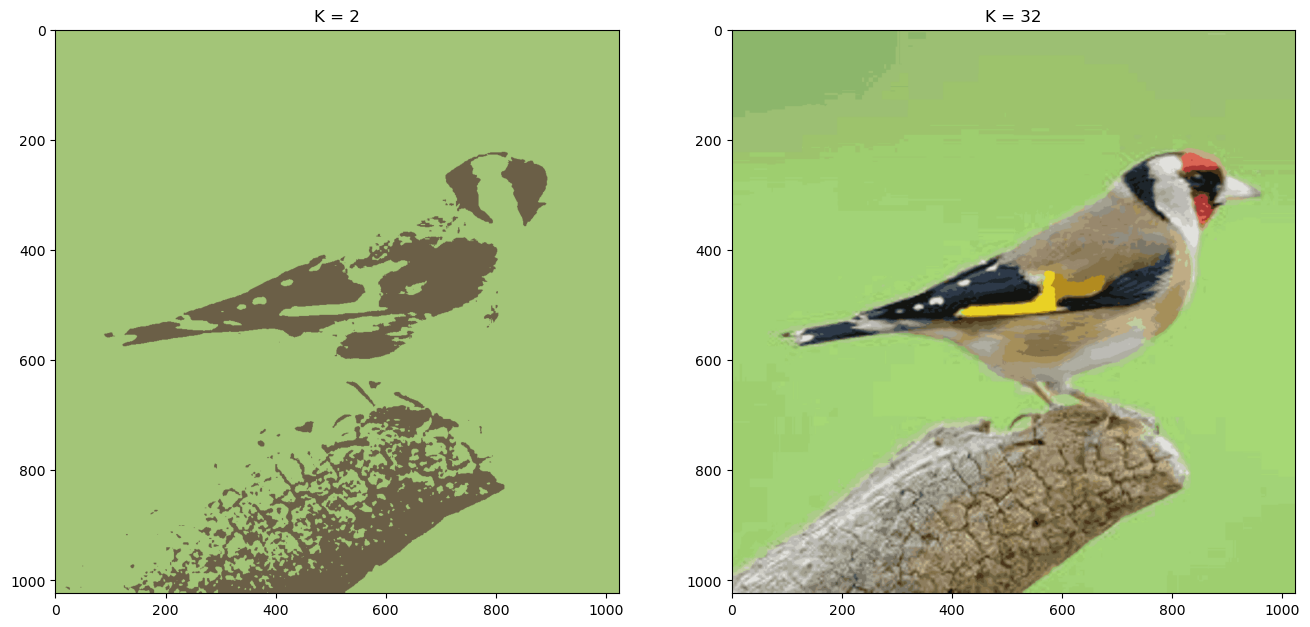

In [43]:
h,w,g=img.shape
#print(img.shape)
Z=img.reshape((-1,3))
Ka=[2,32]

plt.figure(figsize=(16, 12))

label,center=km_clust(Z,K)

for i, K in enumerate(Ka):
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape((img.shape))

    plt.subplot(1, len(Ka), i+1)
    plt.title("K = {}".format(K))
    plt.imshow(res)
  
plt.show()

## 1-2. cluster with RGB values and the location

[[154.41625791 186.4762084  116.98752053 510.55390848 256.33123251]
 [156.48531168 180.33189946 110.43657385 512.45223233 768.32499732]]
[[155.64518505 177.57328621 109.43507235 256.39679474 768.16950692]
 [157.0980738  179.20511235 122.85743848 766.83918829 254.5127465 ]
 [151.85839362 193.99007783 111.27087679 254.56939609 256.36520224]
 [157.18918651 182.87739937 111.33627907 768.11609943 766.69472549]]
[[157.13910657 181.3142628  114.22587872 171.37558278 849.08517674]
 [142.83931055 136.88628295 102.73381489 861.6109275  506.30298915]
 [157.2791367  197.91606206 110.48728334 167.66569132 492.74470206]
 [164.83115964 196.97010622 131.44910782 779.8937977  152.54456952]
 [159.75608071 200.46599377 117.50969201 853.17823808 857.06446377]
 [160.62247655 186.38993959 114.9514359  511.84498042 824.65356243]
 [144.00954094 162.29977474 101.00553544 519.02007365 433.77195532]
 [155.41341126 199.64566262 114.13004858 248.69970612 149.11188626]]
[[137.89109593 138.05217509  90.72911798 890.

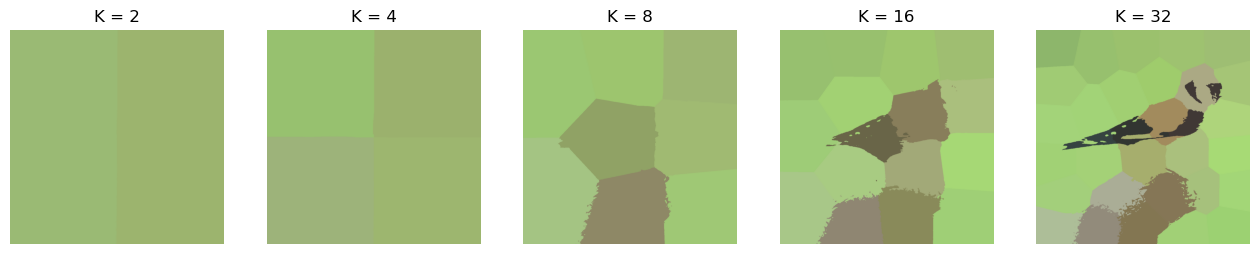

In [44]:
h, w, c = img.shape

#Added location feature
Z = np.zeros((h, w, c+2))
for h in range(len(img)):
    for w in range(len(img[h])):
        Z[h][w] = np.append(img[h][w], [[h], [w]])
Z = Z.reshape(-1, 5)

Ks = [2,4,8,16,32]
plt.figure(figsize=(16,12))

for i, K in enumerate(Ks):
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape((img.shape))

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()

## 1-3. explain the differences between the two methods under the same K.
![](images/7.4_result.PNG)

[[153.23513099 174.74846313 108.17577954 132.93832993 187.62953319]
 [157.92448589 193.11649946 119.93328334 122.20575604  60.96981487]]
[[167.56953512 206.11705494 123.01471568 169.20176849 211.85607137]
 [166.1111815  199.71514618 129.66014953 168.04015862  51.47549004]
 [157.91576711 192.79613019 112.34618938  45.83666388 124.37866238]
 [114.08080224 101.9730278   75.92054607 173.16233883 137.92172283]]
[[160.49600319 195.04470407 109.1779855   56.52642407 124.68111557]
 [167.67712662 199.5880364  133.34388485 187.09984442  53.72080145]
 [137.89762581 124.23945968  91.42659637 198.50554782 132.4835783 ]
 [161.20224614 208.94010303 119.40392917 224.00985683 212.26109251]
 [155.79906194 200.35729748 114.3281738   64.84237189  40.91956533]
 [172.17741664 208.55245372 125.29409359 140.82311652 211.76273561]
 [161.91814247 185.15994958 117.78625561  44.85818417 210.03141796]
 [ 50.47804866  49.68770286  46.72228323 116.90834493 139.56507919]]
[[161.44868136 207.15394036 119.7326075  223.

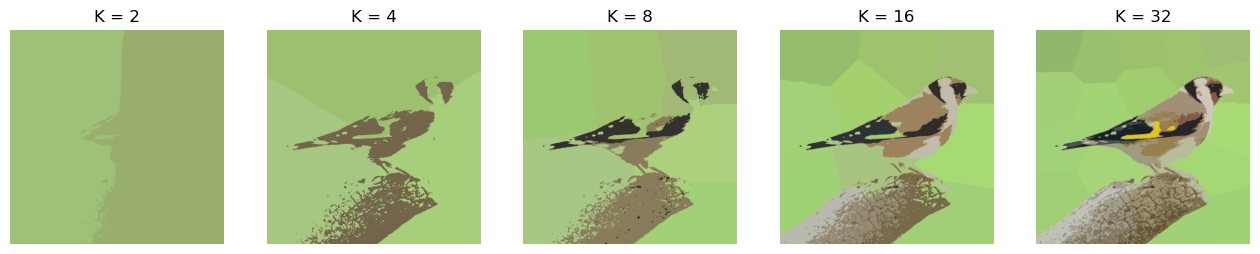

In [45]:
h, w, c = img.shape

#Added location feature
Z = np.zeros((h, w, c+2))
for h in range(len(img)):
    for w in range(len(img[h])):
        Z[h][w] = np.append(img[h][w], [[h/4], [w/4]])
Z = Z.reshape(-1, 5)

Ks = [2,4,8,16,32]
plt.figure(figsize=(16,12))

for i, K in enumerate(Ks):
    label, center = km_clust(Z, K)

    # Now convert back into uint8, and make original image
    center = np.uint8(center[:, :3])
    res = center[label.flatten()]
    res = res.reshape((img.shape))

    plt.subplot(1, 5, i+1)
    plt.axis('off')
    plt.title("K = {}".format(K))
    plt.imshow(res)
    
plt.show()